# Pipeline

### Data Loading and EDA

In [ ]:
# Loads relational tables into DuckDB, prepares data with SQL, and runs EDA

import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import logging

# Configuring logging
logging.basicConfig(
    filename='../../.logs/pipeline.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

# Loading relational tables into DuckDB
con = duckdb.connect()
try: 
    con.execute("CREATE TABLE transactions AS SELECT * FROM read_csv_auto('../../data/relational/transactions.csv')")
    con.execute("CREATE TABLE transaction_types AS SELECT * FROM read_csv_auto('../../data/relational/transaction_types.csv')")
    con.execute("CREATE TABLE time_steps AS SELECT * FROM read_csv_auto('../../data/relational/time_steps.csv')")
    con.execute("CREATE TABLE accounts AS SELECT * FROM read_csv_auto('../../data/relational/accounts.csv')")
    logging.info("Tables created successfully.")
except Exception as e:
    logging.error(f"Error creating tables: {e}")


# SQL query to prepare data for modeling
try:
    df = con.execute("""
        SELECT
          t.amount,
          t.isFraud,
          tt.type_name,
          ts.hour_of_day,
          ts.day_of_month,
          COALESCE(CASE WHEN a.account_type = 'merchant' THEN 1 ELSE 0 END, 0) AS is_merchant
        FROM transactions t
        JOIN transaction_types tt ON t.type_id = tt.type_id
        JOIN time_steps ts ON t.step = ts.step
        LEFT JOIN accounts a ON t.recipient_id = a.account_id
    """).df()
    logging.info(f"Query successful. DataFrame shape: {df.shape}")
except Exception as e:
    logging.error(f"Error executing SQL query: {e}")
    raise

# Performing brief EDA

print(df.shape)
print(df.isnull().sum())
print(df['isFraud'].value_counts())

(6362620, 6)
amount          0
isFraud         0
type_name       0
hour_of_day     0
day_of_month    0
is_merchant     0
dtype: int64
isFraud
0    6354407
1       8213
Name: count, dtype: int64


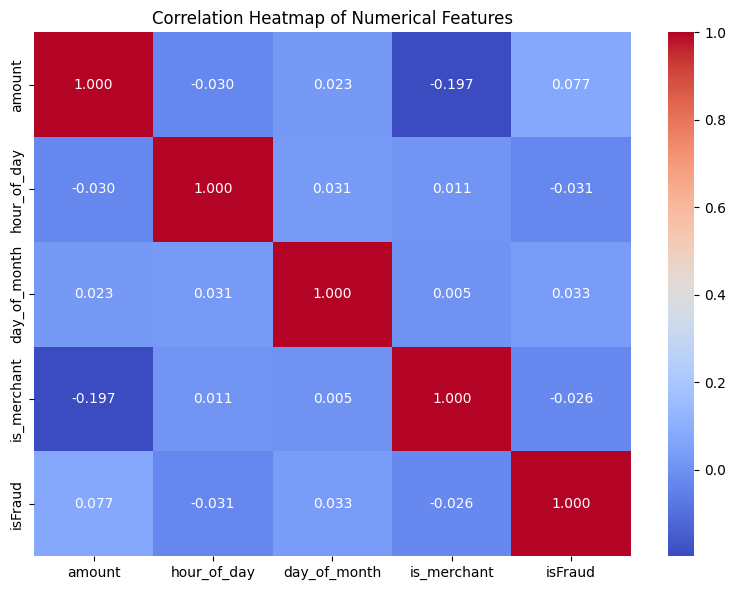

In [2]:
# Correlation heatmap of numerical features
corr = df[['amount', 'hour_of_day', 'day_of_month', 'is_merchant', 'isFraud']].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

### Analysis Rationale

As the predictive features above show little correlation with the outcome variable, I used a gradient boosting classifier to build decision trees sequentially, correcting the errors of previous trees. This model prevents overfitting with its built in regularization in its objective function, as well as in its hyperparameters, which we tune. We handled class imbalance by implementing `scale_pos_weight`, which balances the positive and negative classes. This allows for better model performance, as our current `is_fraud` target label only makes up 0.13% of observations. We used GridSearchCV to find optimal hyperparameters such as the number of estimators, the maximum depth of trees, and the learning rate. Inside the grid search, we implemented stratified K-fold cross-validation, preserving the same class percentage as the whole dataset, ensuring representative train/test sets. This allowed the model to learn patterns based on the same class imbalance proportion in the entire dataset. We used "recall" as the scoring, as minimizing false negatives is more important than minimizing false positives in fraud. This is because missing a fraudulent transaction is more costly for a business and for the customer than flagging a legitimate transaction. 

After performing the cross-validation through grid search, the training recall was approximately 0.90 with learning_rate of 0.1, maximum depth of 3, and 100 estimators. We fit this best model to the test set, resulting in a recall of approximately 0.91, meaning that we catch ~91% of fraudulent transactions. However, the model's precision was ~0.01, meaning that the false positive rate was much too high. This is most likely due to the low predictive performance of the features.

In [3]:
from xgboost import XGBClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import recall_score, f1_score, precision_score, confusion_matrix

# Preparing features

df = pd.get_dummies(df, columns = ['type_name']) # Converting categorical columns to numeric
X = df.drop(columns = ['isFraud']) # Defining predictor variables
y = df['isFraud'] # Defining target variable

# Calculating scale_pos_weight to handle class imbalance
scale_pos_weight = (y == 0).sum() / (y == 1).sum()

# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

model = make_pipeline(StandardScaler(), XGBClassifier(scale_pos_weight = scale_pos_weight, random_state = 42)) # Instantiating the model

# Hyperparameter tuning with GridSearchCV
param_grid = {
    'xgbclassifier__n_estimators': [100, 200, 300],
    'xgbclassifier__max_depth': [3, 5, 7],
    'xgbclassifier__learning_rate': [0.01, 0.1, 0.2]
}

# Using StratifiedKFold to maintain class distribution in folds and optimizing for recall
grid_search = GridSearchCV(
    estimator=model, 
    param_grid=param_grid, 
    cv=StratifiedKFold(n_splits=3), 
    scoring='recall', 
    n_jobs=1,
    verbose=3
)

grid_search.fit(X_train, y_train)


Fitting 3 folds for each of 27 candidates, totalling 81 fits
[CV 1/3] END xgbclassifier__learning_rate=0.01, xgbclassifier__max_depth=3, xgbclassifier__n_estimators=100;, score=0.908 total time=   5.3s
[CV 2/3] END xgbclassifier__learning_rate=0.01, xgbclassifier__max_depth=3, xgbclassifier__n_estimators=100;, score=0.890 total time=   4.5s
[CV 3/3] END xgbclassifier__learning_rate=0.01, xgbclassifier__max_depth=3, xgbclassifier__n_estimators=100;, score=0.897 total time=   4.9s
[CV 1/3] END xgbclassifier__learning_rate=0.01, xgbclassifier__max_depth=3, xgbclassifier__n_estimators=200;, score=0.897 total time=   7.1s
[CV 2/3] END xgbclassifier__learning_rate=0.01, xgbclassifier__max_depth=3, xgbclassifier__n_estimators=200;, score=0.890 total time=   7.0s
[CV 3/3] END xgbclassifier__learning_rate=0.01, xgbclassifier__max_depth=3, xgbclassifier__n_estimators=200;, score=0.897 total time=   8.1s
[CV 1/3] END xgbclassifier__learning_rate=0.01, xgbclassifier__max_depth=3, xgbclassifier__n_

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'xgbclassifier__learning_rate': [0.01, 0.1, ...], 'xgbclassifier__max_depth': [3, 5, ...], 'xgbclassifier__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 

In [7]:
# Best model and its performance
print("Best Hyperparameters:", grid_search.best_params_)
print("Recall:", grid_search.best_score_)

Best Hyperparameters: {'xgbclassifier__learning_rate': 0.1, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 100}
Recall: 0.9037205770690965


In [8]:
# Evaluating the best model on the test set

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Test Set Recall: {recall:.4f}")
print(f"Test Set Precision: {precision:.4f}")
print(f"Test Set F1 Score: {f1:.4f}")

Test Set Recall: 0.9128
Test Set Precision: 0.0112
Test Set F1 Score: 0.0222


### Visualization Rationale

A confusion matrix was chosen to visualize model results because it clearly shows the four possible prediction outcomes: true positives, true negatives, false positives, and false negatives, which are all critical in fraud detection. A log-normalized color scale was applied to handle the extreme class imbalance, ensuring all four cells are visually distinguishable despite the large difference in counts between legitimate and fraudulent transactions.

The model correctly identified 1,486 out of 1,628 fraudulent transactions, achieving a recall of approximately 0.91. However, it also flagged 130,927 legitimate transactions as fraudulent, resulting in a low precision of 0.01. This high false positive rate is expected given the extreme class imbalance and low feature correlation with the fraud label, and represents a known limitation of the current feature set. Future work should focus on engineering stronger predictive features to improve precision without sacrificing recall.

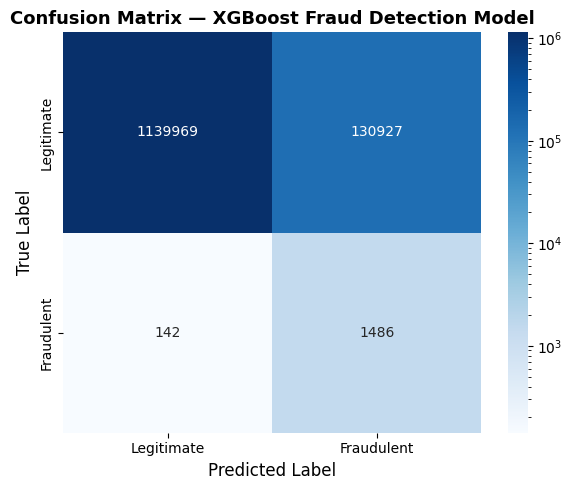

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm

# Visualizing confusion matrix

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Legitimate', 'Fraudulent'],
            yticklabels=['Legitimate', 'Fraudulent'],
            norm=LogNorm())
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix — XGBoost Fraud Detection Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()